# 🍷 Tech Challenge Fase 2 — Classificação da Qualidade de Vinhos

**Objetivo:** Desenvolver um modelo de classificação capaz de prever a qualidade de um vinho com base em suas características físico-químicas.

**Dataset:** Wine Quality Dataset (Kaggle) — vinhos tintos

**Classificação binária:**
- Alta Qualidade: nota ≥ 7
- Baixa/Média Qualidade: nota < 7

**Autores:** Marcelo Abbade, André Vieira, Lívia De Oliveira, Allan Diniz, Matheus Gueicha

**Pós-Graduação:** Data Analytics — FIAP/POS TECH

---
## 1. Importação das Bibliotecas

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


In [37]:
import os

# Detectar automaticamente o diretório base do projeto
# Funciona tanto com caminho relativo quanto absoluto
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))

# Se estamos dentro de notebooks/, subir um nível
if os.path.basename(NOTEBOOK_DIR) == 'notebooks':
    BASE_DIR = os.path.dirname(NOTEBOOK_DIR)
else:
    # Tentar encontrar a pasta data/ a partir do diretório atual
    if os.path.exists(os.path.join(NOTEBOOK_DIR, 'data')):
        BASE_DIR = NOTEBOOK_DIR
    else:
        BASE_DIR = os.path.dirname(NOTEBOOK_DIR)

DATA_DIR = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

# Criar pasta results se não existir
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Diretório base: {BASE_DIR}')
print(f'Diretório de dados: {DATA_DIR}')
print(f'Diretório de resultados: {RESULTS_DIR}')

Diretório base: c:\Users\USER\Desktop\Marcelo\Pós FIAP DT13\Pos Tech Data Analytics FIAP\Fase 2 - Machine Learning e IA\Tech Challenge II
Diretório de dados: c:\Users\USER\Desktop\Marcelo\Pós FIAP DT13\Pos Tech Data Analytics FIAP\Fase 2 - Machine Learning e IA\Tech Challenge II\data
Diretório de resultados: c:\Users\USER\Desktop\Marcelo\Pós FIAP DT13\Pos Tech Data Analytics FIAP\Fase 2 - Machine Learning e IA\Tech Challenge II\results


---
## 2. Carregamento e Compreensão do Problema

### 2.1 Contexto

A indústria vitivinícola tradicionalmente avalia a qualidade dos vinhos por meio de análises sensoriais realizadas por especialistas — um processo subjetivo, demorado e dependente da experiência dos avaliadores.

Este projeto propõe utilizar **dados físico-químicos** obtidos durante a produção do vinho para **prever automaticamente** se um vinho é de alta ou baixa/média qualidade, apoiando enólogos e produtores na tomada de decisão.

### 2.2 Variável Alvo

A variável `quality` (nota de 0 a 10 atribuída por especialistas) será transformada em classificação **binária**:
- **1 (Alta Qualidade):** nota ≥ 7
- **0 (Baixa/Média Qualidade):** nota < 7

### 2.3 Carregamento dos Dados

In [38]:
df_raw = pd.read_csv(r'C:\Users\USER\Documents\GitHub\TechChallengeF2\data\winequality-red.csv')
print(f'Dataset carregado: {df_raw.shape[0]} amostras e {df_raw.shape[1]} variáveis')
df_raw.head(10)

Dataset carregado: 1599 amostras e 12 variáveis


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [39]:
print('=== Informações do Dataset ===')
print()
df_raw.info()

=== Informações do Dataset ===

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [40]:
print('=== Estatísticas Descritivas ===')
df_raw.describe().round(3)

=== Estatísticas Descritivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [41]:
print('=== Verificação de Dados Faltantes ===')
missing = df_raw.isnull().sum()
print(missing)
print(f'\nTotal de valores faltantes: {missing.sum()}')
print('\n✅ Nenhum valor faltante encontrado — dataset completo.')

=== Verificação de Dados Faltantes ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores faltantes: 0

✅ Nenhum valor faltante encontrado — dataset completo.


### 2.4 Análise e Tratamento de Duplicatas

Uma etapa fundamental da limpeza de dados é verificar a existência de **registros duplicados exatos** — linhas onde todas as colunas possuem valores idênticos.

No contexto de Machine Learning, duplicatas podem causar:
- **Data leakage:** se um registro duplicado aparece tanto no conjunto de treino quanto no de teste, o modelo é avaliado com dados que já "viu", inflando as métricas artificialmente.
- **Viés de treinamento:** o modelo dá peso desproporcional a perfis repetidos, prejudicando a generalização.
- **Distorção na EDA:** distribuições e correlações ficam enviesadas por padrões superrepresentados.

In [42]:
print('=== Análise Detalhada de Duplicatas ===')
n_duplicatas = df_raw.duplicated().sum()
pct_duplicatas = n_duplicatas / len(df_raw) * 100

print(f'Total de registros: {len(df_raw)}')
print(f'Registros duplicados exatos: {n_duplicatas}')
print(f'Percentual de duplicatas: {pct_duplicatas:.2f}%')
print()

# Mostrar exemplos de duplicatas
print('=== Exemplos de registros duplicados ===')
duplicated_rows = df_raw[df_raw.duplicated(keep=False)].sort_values(by=df_raw.columns.tolist())
print(f'Total de linhas envolvidas em duplicação (incluindo originais): {len(duplicated_rows)}')
print()
duplicated_rows.head(10)

=== Análise Detalhada de Duplicatas ===
Total de registros: 1599
Registros duplicados exatos: 240
Percentual de duplicatas: 15.01%

=== Exemplos de registros duplicados ===
Total de linhas envolvidas em duplicação (incluindo originais): 460



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
142,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
144,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6
131,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5
132,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5
1488,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.99420,3.72,0.58,11.4,5
1491,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.99420,3.72,0.58,11.4,5
996,5.6,0.66,0.00,2.2,0.087,3.0,11.0,0.99378,3.71,0.63,12.8,7
997,5.6,0.66,0.00,2.2,0.087,3.0,11.0,0.99378,3.71,0.63,12.8,7
829,5.9,0.61,0.08,2.1,0.071,16.0,24.0,0.99376,3.56,0.77,11.1,6
831,5.9,0.61,0.08,2.1,0.071,16.0,24.0,0.99376,3.56,0.77,11.1,6


In [43]:
# Análise: quantas vezes cada registro duplicado aparece
print('=== Frequência das duplicações ===')
dup_counts = df_raw.groupby(df_raw.columns.tolist()).size().reset_index(name='count')
dup_counts_filtered = dup_counts[dup_counts['count'] > 1].sort_values('count', ascending=False)
print(f'Registros únicos que possuem duplicatas: {len(dup_counts_filtered)}')
print(f'\nDistribuição da frequência de repetição:')
print(dup_counts_filtered['count'].value_counts().sort_index())
print()
print('Top 5 registros mais duplicados:')
dup_counts_filtered.head()

=== Frequência das duplicações ===
Registros únicos que possuem duplicatas: 220

Distribuição da frequência de repetição:
count
2    204
3     12
4      4
Name: count, dtype: int64

Top 5 registros mais duplicados:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,count
182,6.7,0.460,0.24,1.7,0.077,18.0,34.0,0.99480,3.39,0.60,10.6,6,4
497,7.5,0.510,0.02,1.7,0.084,13.0,31.0,0.99538,3.36,0.54,10.5,6,4
405,7.2,0.695,0.13,2.0,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5,4
367,7.2,0.360,0.46,2.1,0.074,24.0,44.0,0.99534,3.40,0.85,11.0,7,4
308,7.0,0.690,0.07,2.5,0.091,15.0,21.0,0.99572,3.38,0.60,11.3,6,3


=== Quality nos duplicados vs únicos ===


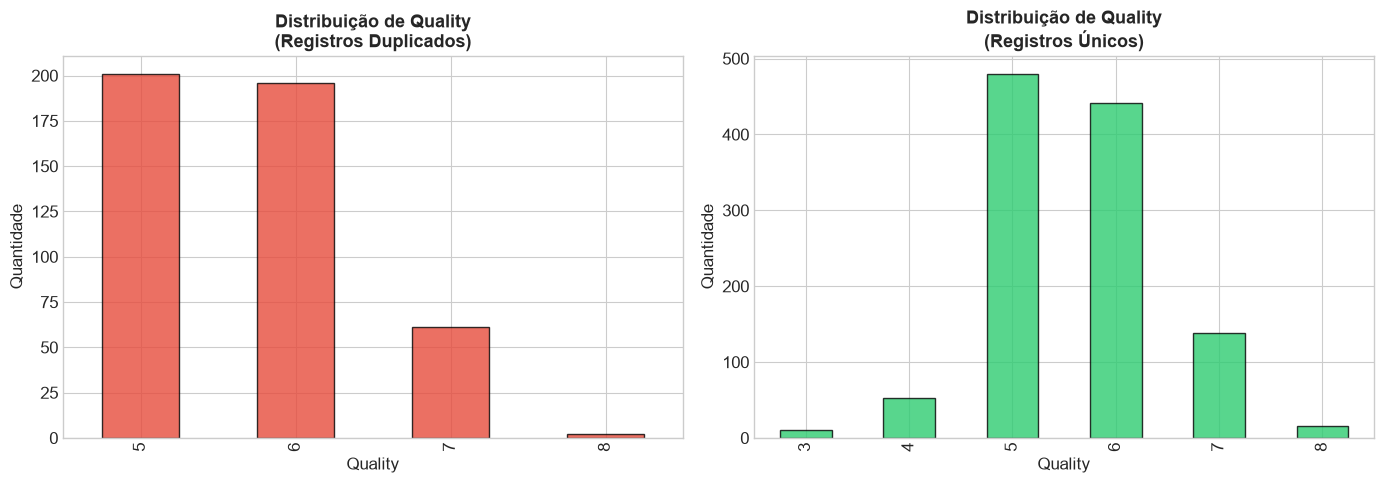

In [44]:
# Distribuição de quality nos registros duplicados vs não-duplicados
print('=== Quality nos duplicados vs únicos ===')
df_raw['is_duplicate'] = df_raw.duplicated(keep=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duplicados
df_raw[df_raw['is_duplicate']]['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black', alpha=0.8
)
axes[0].set_title('Distribuição de Quality\n(Registros Duplicados)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Quantidade')

# Únicos
df_raw[~df_raw['is_duplicate']]['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#2ecc71', edgecolor='black', alpha=0.8
)
axes[1].set_title('Distribuição de Quality\n(Registros Únicos)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'duplicatas_analise.png'), dpi=150, bbox_inches='tight')
plt.show()

# Limpar coluna auxiliar
df_raw.drop('is_duplicate', axis=1, inplace=True)

In [45]:
# DECISÃO: Remover duplicatas
print('=== Remoção de Duplicatas ===')
print(f'Registros antes da remoção: {len(df_raw)}')

df = df_raw.drop_duplicates(keep='first').reset_index(drop=True)

print(f'Registros após remoção: {len(df)}')
print(f'Registros removidos: {len(df_raw) - len(df)}')
print()
print('✅ Duplicatas removidas com sucesso.')
print('📌 Justificativa: evitar data leakage, viés de treinamento e distorção na EDA.')

=== Remoção de Duplicatas ===
Registros antes da remoção: 1599
Registros após remoção: 1359
Registros removidos: 240

✅ Duplicatas removidas com sucesso.
📌 Justificativa: evitar data leakage, viés de treinamento e distorção na EDA.


### 2.5 Criação da Variável Alvo (Classificação Binária)

=== Distribuição Original da Variável Quality ===
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


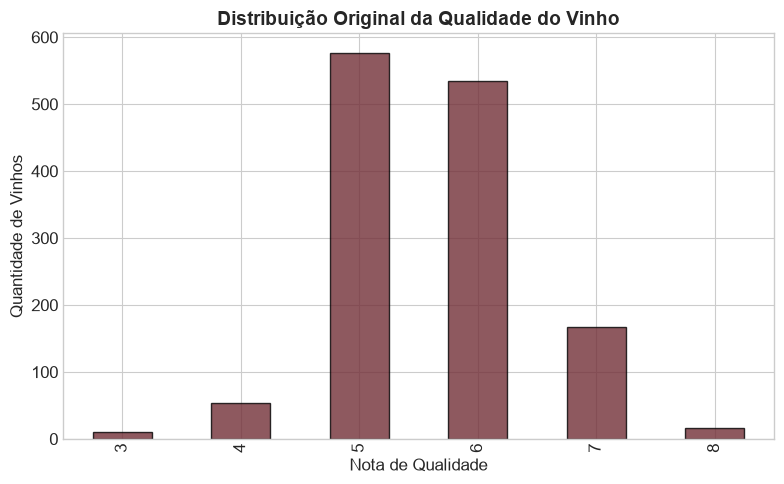

In [46]:
# Distribuição original da variável quality
print('=== Distribuição Original da Variável Quality ===')
print(df['quality'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(
    kind='bar', color='#722F37', edgecolor='black', alpha=0.8, ax=ax
)
ax.set_title('Distribuição Original da Qualidade do Vinho', fontsize=14, fontweight='bold')
ax.set_xlabel('Nota de Qualidade')
ax.set_ylabel('Quantidade de Vinhos')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'distribuicao_quality_original.png'), dpi=150, bbox_inches='tight')
plt.show()

=== Classificação Binária ===
Alta Qualidade (≥7): 184 vinhos
Baixa/Média Qualidade (<7): 1175 vinhos


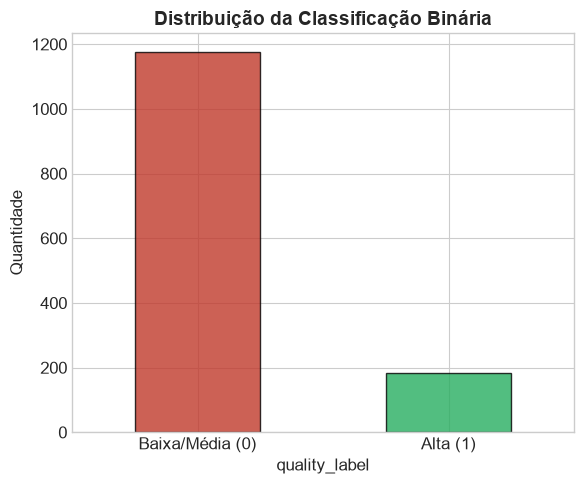

In [47]:
# Criação da variável binária
df['quality_label'] = (df['quality'] >= 7).astype(int)

print('=== Classificação Binária ===')
print(f'Alta Qualidade (≥7): {df["quality_label"].sum()} vinhos')
print(f'Baixa/Média Qualidade (<7): {(df["quality_label"] == 0).sum()} vinhos')

fig, ax = plt.subplots(figsize=(6, 5))
df['quality_label'].value_counts().plot(
    kind='bar', color=['#c0392b', '#27ae60'], edgecolor='black', alpha=0.8, ax=ax
)
ax.set_title('Distribuição da Classificação Binária', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Baixa/Média (0)', 'Alta (1)'], rotation=0)
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'distribuicao_quality_binaria.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição das Variáveis

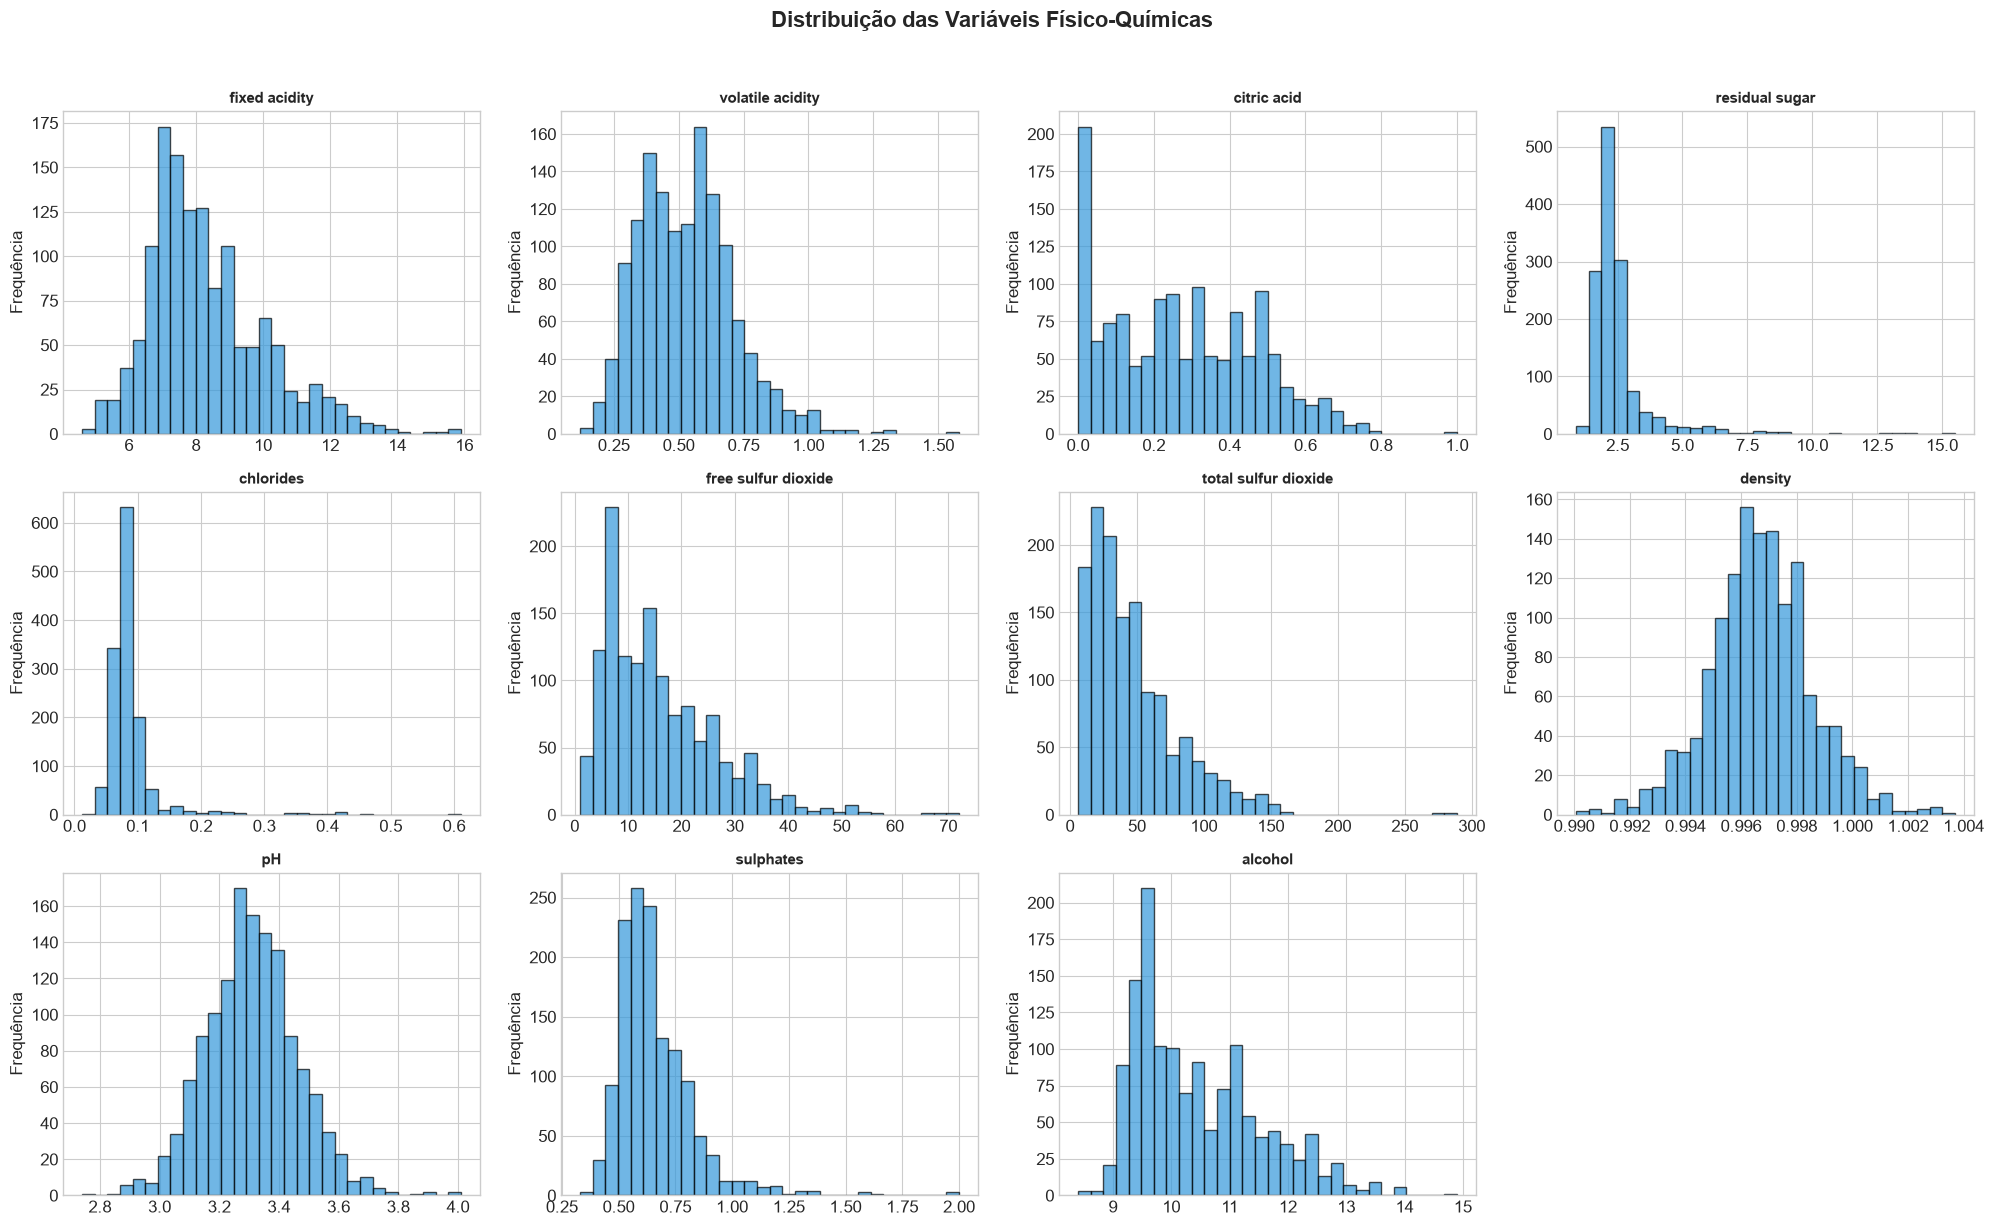

In [48]:
features = df.columns.drop(['quality', 'quality_label'])

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frequência')

# Remover subplot extra
if len(features) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribuição das Variáveis Físico-Químicas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'distribuicao_variaveis.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Distribuição das Variáveis por Classe de Qualidade

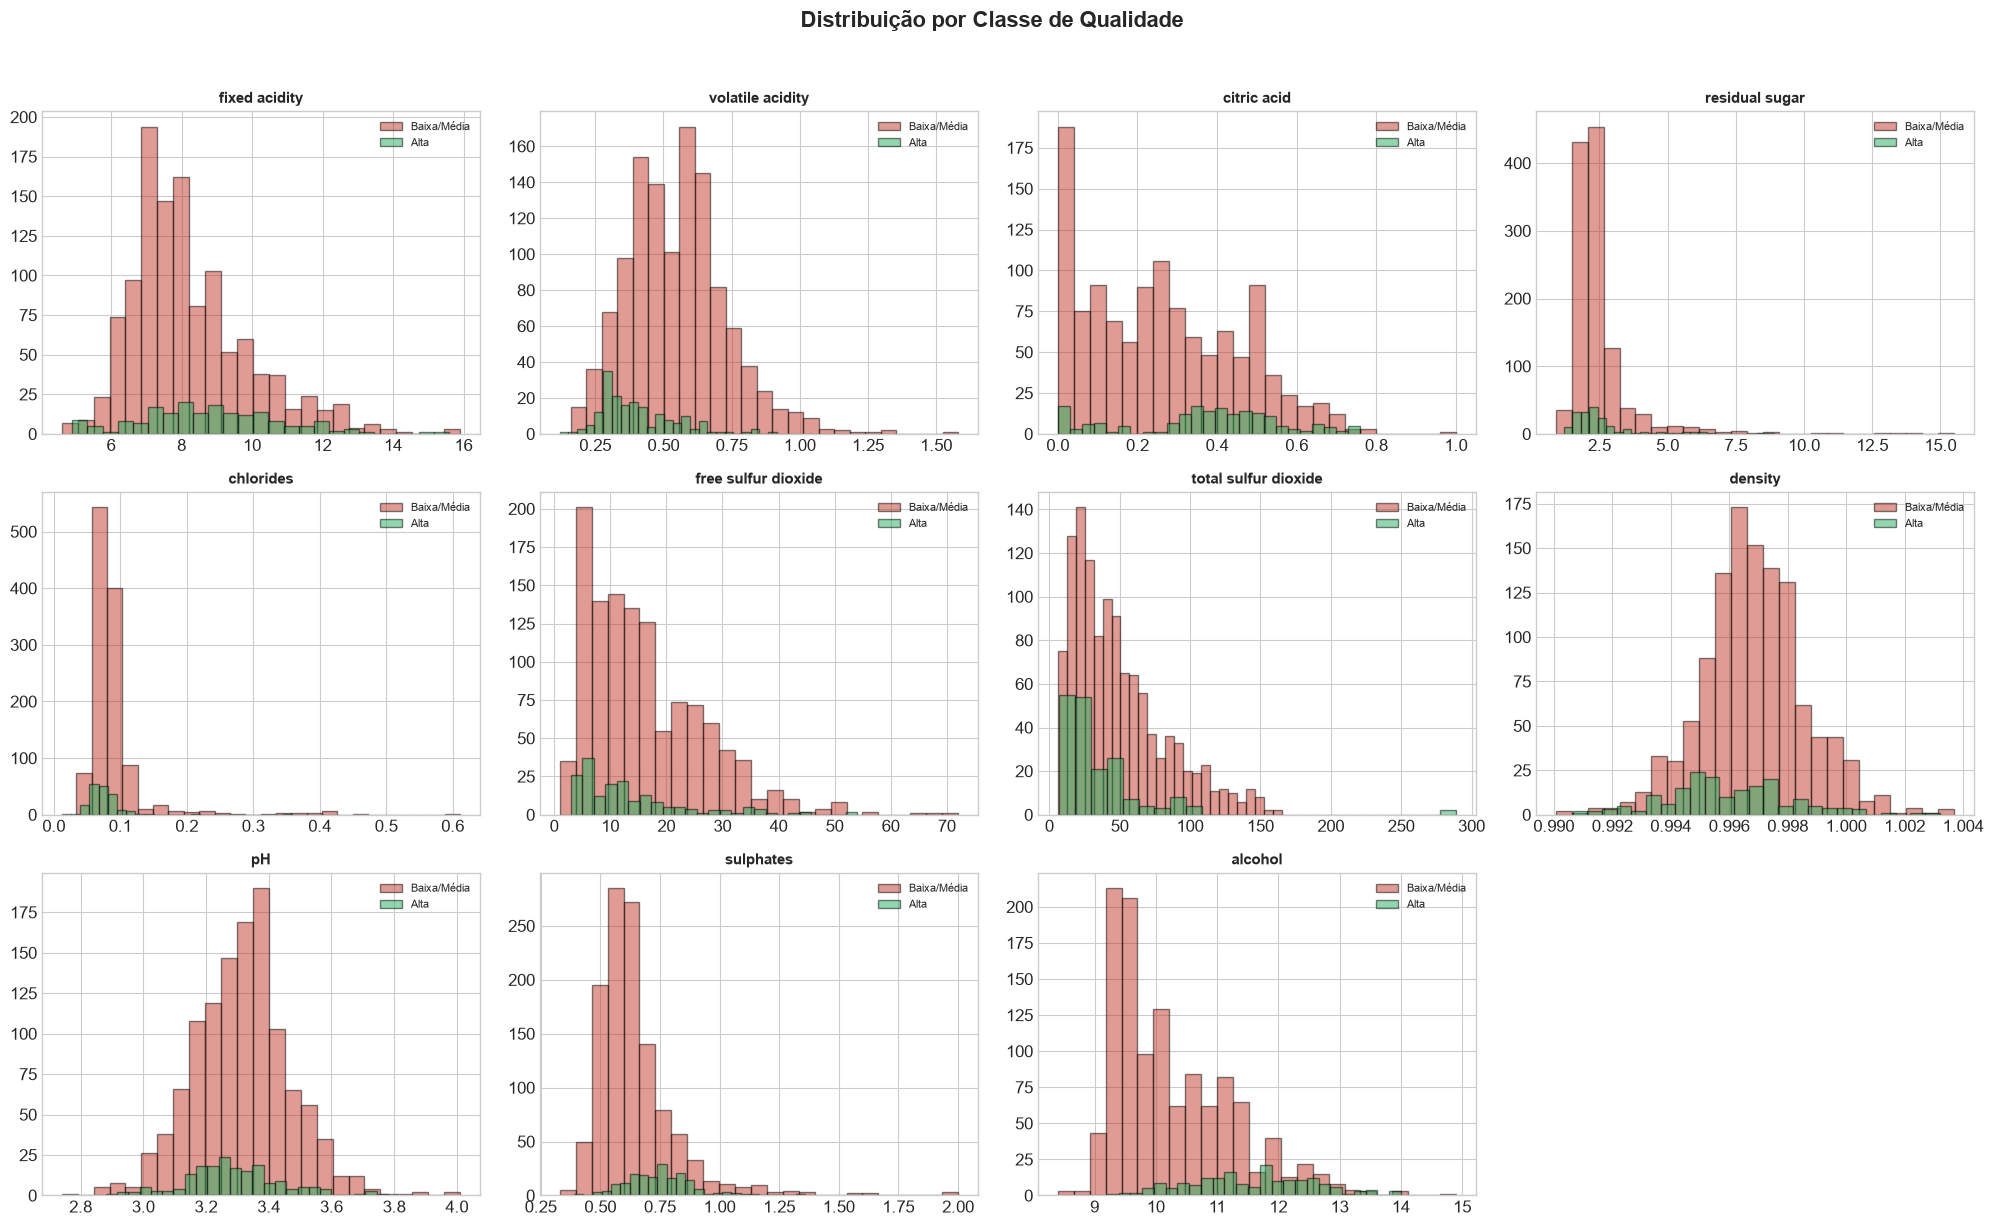

In [49]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, color, name in [(0, '#c0392b', 'Baixa/Média'), (1, '#27ae60', 'Alta')]:
        subset = df[df['quality_label'] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.5, color=color, label=name, edgecolor='black')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

if len(features) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Distribuição por Classe de Qualidade', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'distribuicao_por_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Boxplots — Identificação de Outliers

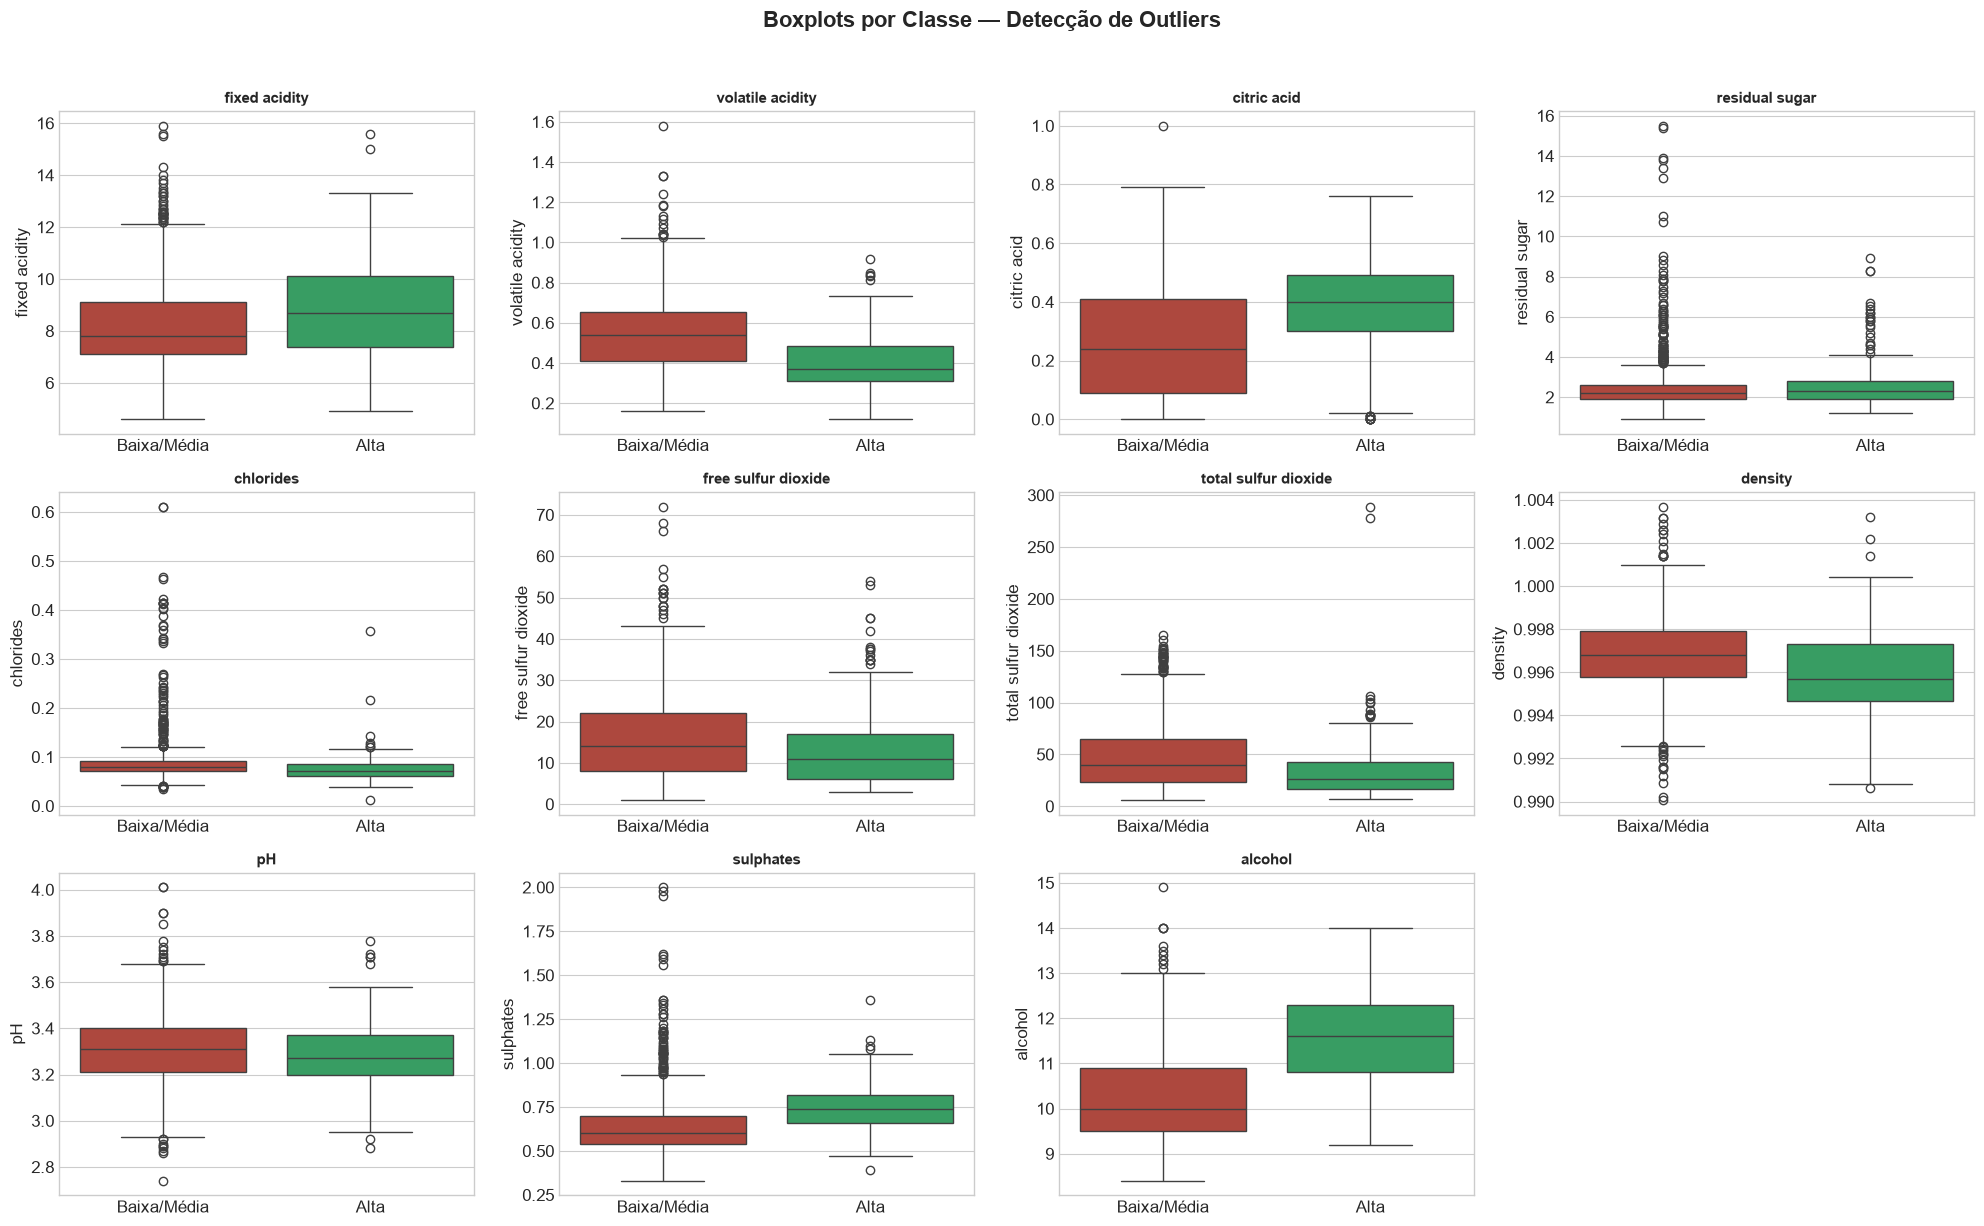

=== Contagem de Outliers (Método IQR) ===
            fixed acidity:   41 outliers (3.0%)
         volatile acidity:   19 outliers (1.4%)
              citric acid:    1 outliers (0.1%)
           residual sugar:  126 outliers (9.3%)
                chlorides:   87 outliers (6.4%)
      free sulfur dioxide:   26 outliers (1.9%)
     total sulfur dioxide:   45 outliers (3.3%)
                  density:   35 outliers (2.6%)
                       pH:   28 outliers (2.1%)
                sulphates:   55 outliers (4.0%)
                  alcohol:   12 outliers (0.9%)


In [50]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

colors = ['#c0392b', '#27ae60']

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, hue='quality_label',
                ax=axes[i], palette=colors, legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Baixa/Média', 'Alta'])

if len(features) < len(axes):
    axes[-1].set_visible(False)

plt.suptitle('Boxplots por Classe — Detecção de Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'boxplots_outliers.png'), dpi=150, bbox_inches='tight')
plt.show()

# Contagem de outliers por variável (método IQR)
print('=== Contagem de Outliers (Método IQR) ===')
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers / len(df) * 100
    print(f'{col:>25s}: {outliers:4d} outliers ({pct:.1f}%)')

### 3.4 Matriz de Correlação

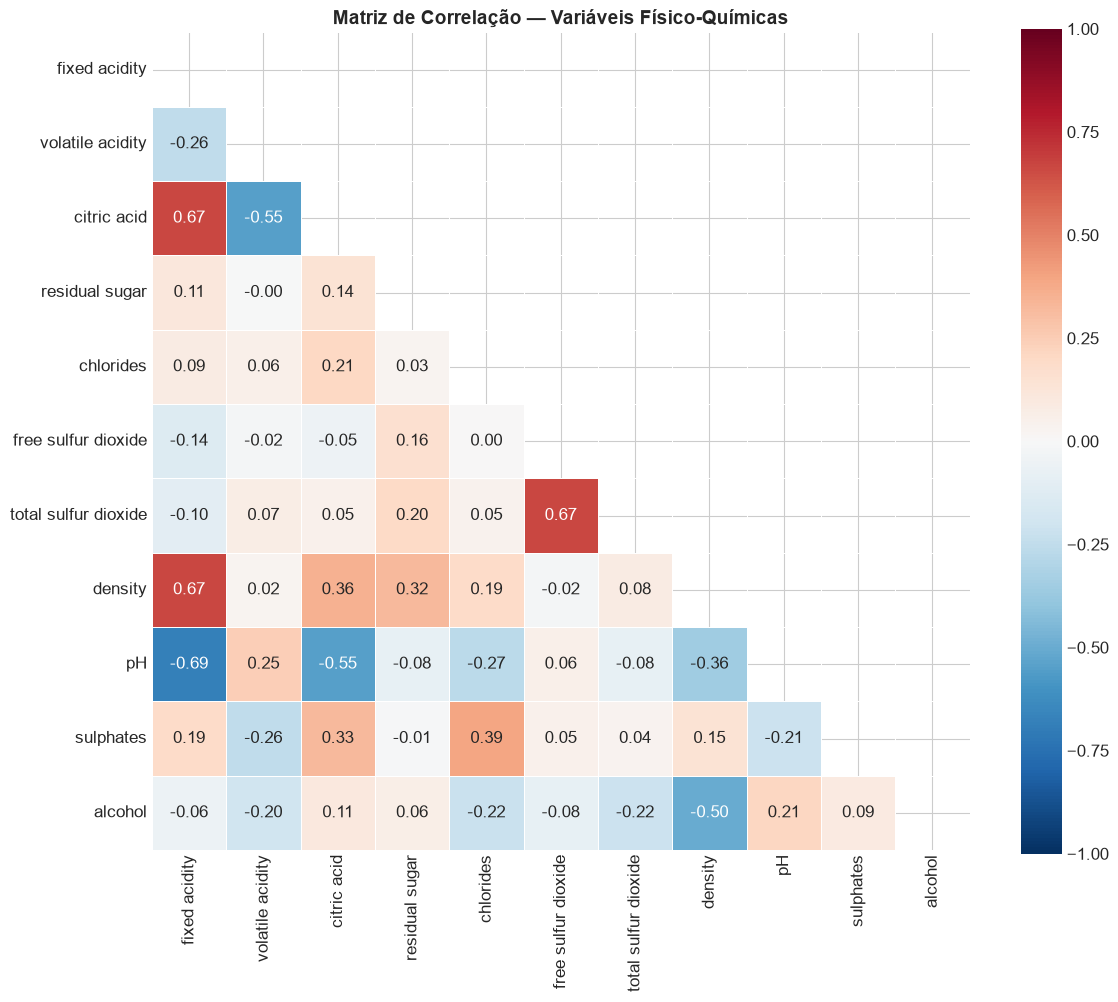

In [51]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação — Variáveis Físico-Químicas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'matriz_correlacao.png'), dpi=150, bbox_inches='tight')
plt.show()

=== Correlação com Quality Label ===


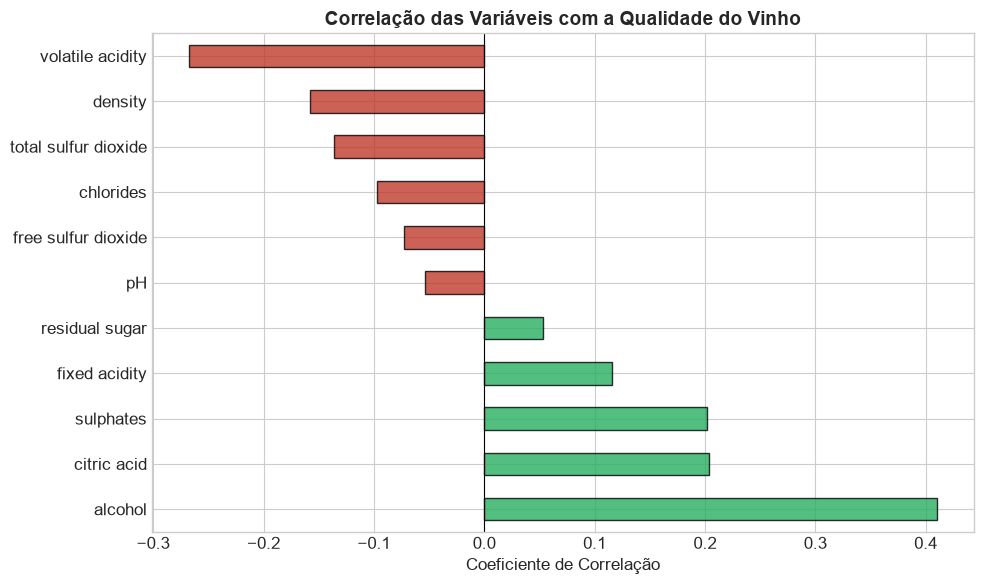

alcohol                 0.410
citric acid             0.204
sulphates               0.202
fixed acidity           0.116
residual sugar          0.053
pH                     -0.054
free sulfur dioxide    -0.073
chlorides              -0.097
total sulfur dioxide   -0.136
density                -0.158
volatile acidity       -0.267
dtype: float64


In [52]:
# Correlação de cada variável com a variável alvo
print('=== Correlação com Quality Label ===')
corr_target = df[features].corrwith(df['quality_label']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if x > 0 else '#c0392b' for x in corr_target.values]
corr_target.plot(kind='barh', color=colors, edgecolor='black', alpha=0.8, ax=ax)
ax.set_title('Correlação das Variáveis com a Qualidade do Vinho', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'correlacao_com_quality.png'), dpi=150, bbox_inches='tight')
plt.show()

print(corr_target.round(3))

### 3.5 Análise e Justificativa das Correlações

**Correlações positivas com qualidade:**
- **Alcohol:** Correlação positiva mais forte (~0.48) — vinhos com maior teor alcoólico tendem a ser de maior qualidade. Álcool é produto da fermentação de açúcares, e uvas mais maduras produzem vinhos com mais álcool e sabores mais complexos.
- **Sulphates:** Correlação positiva (~0.25) — sulfatos atuam como conservantes e antioxidantes, preservando aromas e sabores.
- **Citric acid:** Correlação positiva (~0.21) — contribui para o frescor e equilíbrio do vinho.

**Correlações negativas com qualidade:**
- **Volatile acidity:** Correlação negativa mais forte (~-0.39) — acidez volátil em excesso indica presença de ácido acético (vinagre), resultando em sabor desagradável.
- **Density:** Correlação negativa (~-0.18) — vinhos menos densos geralmente têm mais álcool e menos açúcar residual.
- **Total sulfur dioxide:** Correlação negativa fraca (~-0.15) — excesso de SO₂ pode mascarar aromas.

**Correlações entre features (multicolinearidade):**
- **Fixed acidity × Citric acid:** Correlação positiva forte (~0.67) — ambos são ácidos presentes no vinho.
- **Fixed acidity × Density:** Correlação positiva forte (~0.67) — ácidos contribuem para a densidade.
- **Fixed acidity × pH:** Correlação negativa forte (~-0.68) — relação inversa natural entre acidez e pH.
- **Free sulfur dioxide × Total sulfur dioxide:** Correlação positiva (~0.67) — o SO₂ livre é componente do total.

### 3.6 Análise do Balanceamento das Classes

In [53]:
print('=== Balanceamento das Classes ===')
class_counts = df['quality_label'].value_counts()
class_pct = df['quality_label'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({
    'Classe': ['Baixa/Média Qualidade (0)', 'Alta Qualidade (1)'],
    'Quantidade': class_counts.values,
    'Percentual (%)': class_pct.values.round(1)
})
print(balance_df.to_string(index=False))

ratio = class_counts[0] / class_counts[1]
print(f'\nRazão de desbalanceamento: {ratio:.1f}:1')
print('\n⚠️ O dataset é DESBALANCEADO. A classe de alta qualidade é minoritária.')
print('Isso será tratado na etapa de modelagem (ex: class_weight, SMOTE, etc.).')

=== Balanceamento das Classes ===
                   Classe  Quantidade  Percentual (%)
Baixa/Média Qualidade (0)        1175            86.5
       Alta Qualidade (1)         184            13.5

Razão de desbalanceamento: 6.4:1

⚠️ O dataset é DESBALANCEADO. A classe de alta qualidade é minoritária.
Isso será tratado na etapa de modelagem (ex: class_weight, SMOTE, etc.).


---
## 4. Pré-processamento de Dados

### 4.1 Separação Treino/Teste

In [54]:
# Separar features e target
X = df[features].copy()
y = df['quality_label'].copy()

# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Conjunto de Treino: {X_train.shape[0]} amostras')
print(f'Conjunto de Teste:  {X_test.shape[0]} amostras')
print(f'\nDistribuição no treino:')
print(y_train.value_counts())
print(f'\nDistribuição no teste:')
print(y_test.value_counts())

Conjunto de Treino: 1087 amostras
Conjunto de Teste:  272 amostras

Distribuição no treino:
quality_label
0    940
1    147
Name: count, dtype: int64

Distribuição no teste:
quality_label
0    235
1     37
Name: count, dtype: int64


### 4.2 Feature Engineering

Criação de novas variáveis derivadas que podem capturar relações não-lineares entre as features originais:

In [55]:
def create_features(df_input):
    """Cria novas features derivadas."""
    df_new = df_input.copy()
    
    # Acidez total (fixa + volátil)
    df_new['total_acidity'] = df_new['fixed acidity'] + df_new['volatile acidity']
    
    # Razão SO2 livre / SO2 total
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-6)
    
    # Razão álcool / acidez volátil
    df_new['alcohol_acidity_ratio'] = df_new['alcohol'] / (df_new['volatile acidity'] + 1e-6)
    
    # Razão álcool / densidade
    df_new['alcohol_density_ratio'] = df_new['alcohol'] / df_new['density']
    
    return df_new

X_train_eng = create_features(X_train)
X_test_eng = create_features(X_test)

print(f'Features originais: {X_train.shape[1]}')
print(f'Features após engenharia: {X_train_eng.shape[1]}')
print(f'\nNovas features criadas:')
new_feats = [c for c in X_train_eng.columns if c not in X_train.columns]
for f in new_feats:
    print(f'  • {f}')

Features originais: 11
Features após engenharia: 15

Novas features criadas:
  • total_acidity
  • so2_ratio
  • alcohol_acidity_ratio
  • alcohol_density_ratio


### 4.3 Padronização (StandardScaler)

In [56]:
scaler = StandardScaler()

# Fit APENAS no treino (evitar data leakage)
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_eng),
    columns=X_train_eng.columns,
    index=X_train_eng.index
)

# Transform no teste (usando parâmetros do treino)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_eng),
    columns=X_test_eng.columns,
    index=X_test_eng.index
)

print('✅ Padronização aplicada (fit no treino, transform no teste)')
print(f'\nMédia das features no treino (deve ser ~0):')
print(X_train_scaled.mean().round(2).to_string())

✅ Padronização aplicada (fit no treino, transform no teste)

Média das features no treino (deve ser ~0):
fixed acidity            0.0
volatile acidity         0.0
citric acid              0.0
residual sugar          -0.0
chlorides               -0.0
free sulfur dioxide      0.0
total sulfur dioxide    -0.0
density                 -0.0
pH                       0.0
sulphates                0.0
alcohol                 -0.0
total_acidity            0.0
so2_ratio                0.0
alcohol_acidity_ratio    0.0
alcohol_density_ratio    0.0


### 4.4 Balanceamento com SMOTE

In [57]:
print('=== Balanceamento com SMOTE ===')
print(f'Antes do SMOTE: {y_train.value_counts().to_dict()}')

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f'Após o SMOTE:  {pd.Series(y_train_balanced).value_counts().to_dict()}')
print()
print('✅ SMOTE aplicado APENAS no conjunto de treino.')
print('📌 O conjunto de teste permanece inalterado para avaliação realista.')

=== Balanceamento com SMOTE ===
Antes do SMOTE: {0: 940, 1: 147}
Após o SMOTE:  {0: 940, 1: 940}

✅ SMOTE aplicado APENAS no conjunto de treino.
📌 O conjunto de teste permanece inalterado para avaliação realista.


---
## 5. Desenvolvimento de Modelos

Treinaremos 3 modelos de classificação e compararemos seus desempenhos:
1. **Regressão Logística** — modelo linear baseline
2. **Random Forest** — ensemble de árvores de decisão
3. **Gradient Boosting** — ensemble com boosting sequencial

In [58]:
# Definição dos modelos
models = {
    'Regressão Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=200, max_depth=5)
}

# Treinamento e avaliação
results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f'\n{"="*60}')
    print(f'Treinando: {name}')
    print(f'{"="*60}')
    
    # Treinar
    model.fit(X_train_balanced, y_train_balanced)
    
    # Prever
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc
    }
    predictions[name] = y_pred
    probabilities[name] = y_prob
    
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    print(f'AUC-ROC:   {auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta']))


Treinando: Regressão Logística
Accuracy:  0.7610
Precision: 0.3444
Recall:    0.8378
F1-Score:  0.4882
AUC-ROC:   0.8950

              precision    recall  f1-score   support

 Baixa/Média       0.97      0.75      0.84       235
        Alta       0.34      0.84      0.49        37

    accuracy                           0.76       272
   macro avg       0.66      0.79      0.67       272
weighted avg       0.88      0.76      0.80       272


Treinando: Random Forest
Accuracy:  0.8419
Precision: 0.4375
Recall:    0.5676
F1-Score:  0.4941
AUC-ROC:   0.8751

              precision    recall  f1-score   support

 Baixa/Média       0.93      0.89      0.91       235
        Alta       0.44      0.57      0.49        37

    accuracy                           0.84       272
   macro avg       0.68      0.73      0.70       272
weighted avg       0.86      0.84      0.85       272


Treinando: Gradient Boosting
Accuracy:  0.8676
Precision: 0.5135
Recall:    0.5135
F1-Score:  0.5135
AUC-

In [59]:
# Validação Cruzada (5-fold estratificada)
print('=== Validação Cruzada (5-Fold Estratificada) ===')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    print(f'{name:25s} — AUC médio: {scores.mean():.4f} (±{scores.std():.4f})')

=== Validação Cruzada (5-Fold Estratificada) ===
Regressão Logística       — AUC médio: 0.8525 (±0.0298)
Random Forest             — AUC médio: 0.8617 (±0.0311)
Gradient Boosting         — AUC médio: 0.8544 (±0.0305)


---
## 6. Avaliação dos Modelos

### 6.1 Comparação de Métricas

=== Comparação dos Modelos ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regressão Logística    0.7610     0.3444  0.8378    0.4882   0.8950
Random Forest          0.8419     0.4375  0.5676    0.4941   0.8751
Gradient Boosting      0.8676     0.5135  0.5135    0.5135   0.8852


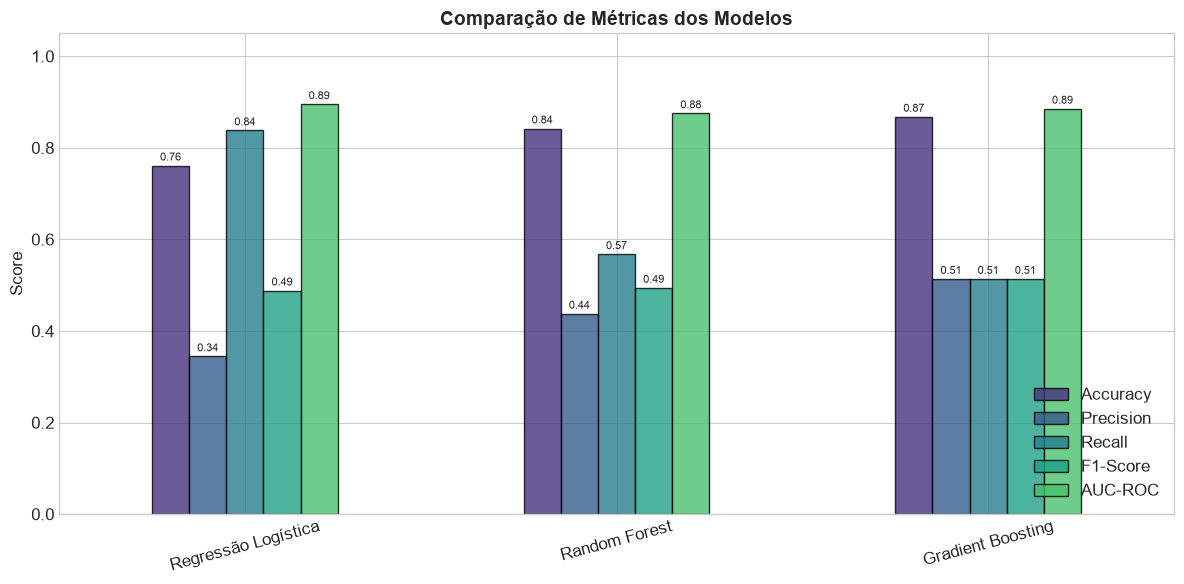

In [60]:
results_df = pd.DataFrame(results).T
print('=== Comparação dos Modelos ===')
print(results_df.round(4).to_string())

# Gráfico de comparação
fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.8)
ax.set_title('Comparação de Métricas dos Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(loc='lower right')

# Adicionar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'comparacao_metricas.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Matrizes de Confusão

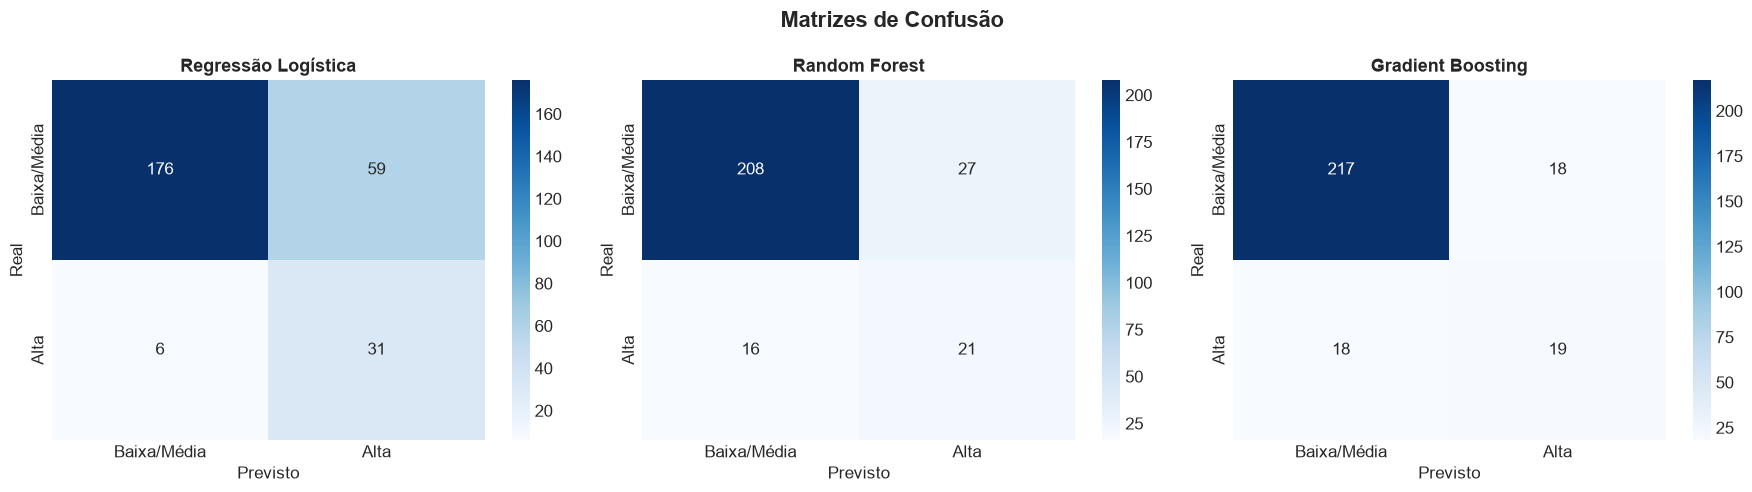

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Baixa/Média', 'Alta'],
                yticklabels=['Baixa/Média', 'Alta'])
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Previsto')

plt.suptitle('Matrizes de Confusão', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'matrizes_confusao.png'), dpi=150, bbox_inches='tight')
plt.show()

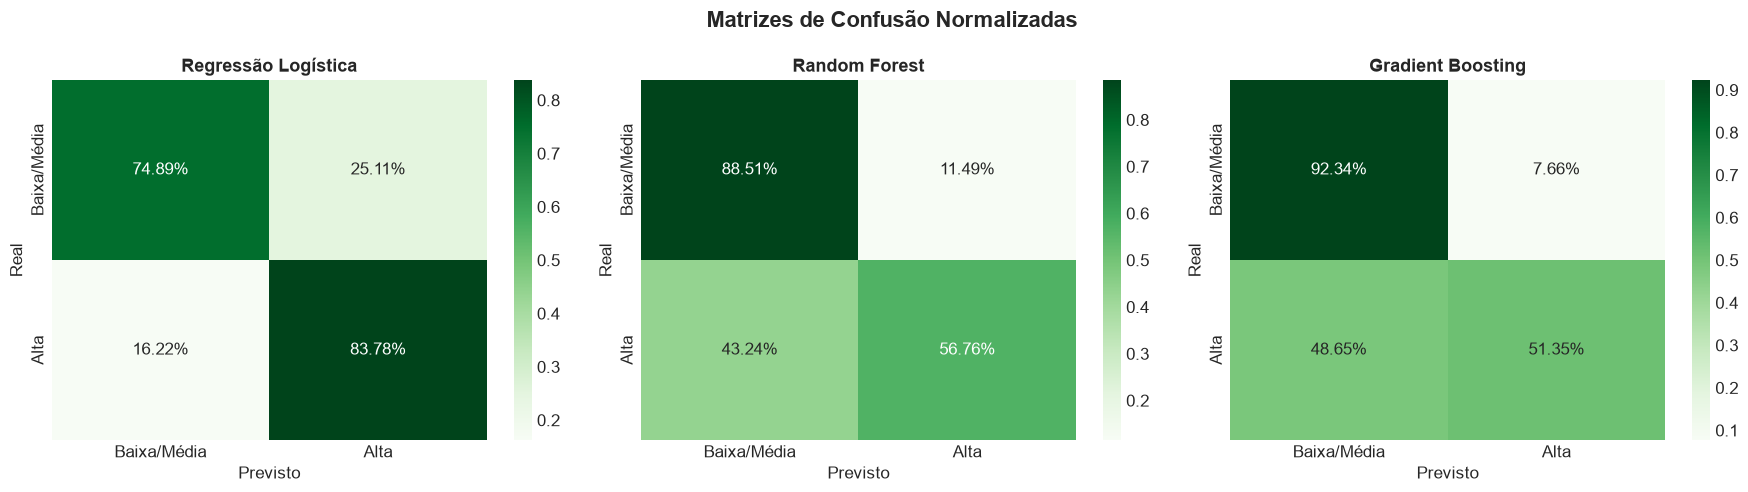

In [62]:
# Matrizes normalizadas (percentual)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Greens', ax=axes[i],
                xticklabels=['Baixa/Média', 'Alta'],
                yticklabels=['Baixa/Média', 'Alta'])
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Previsto')

plt.suptitle('Matrizes de Confusão Normalizadas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'matriz_normalizada.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Curvas ROC

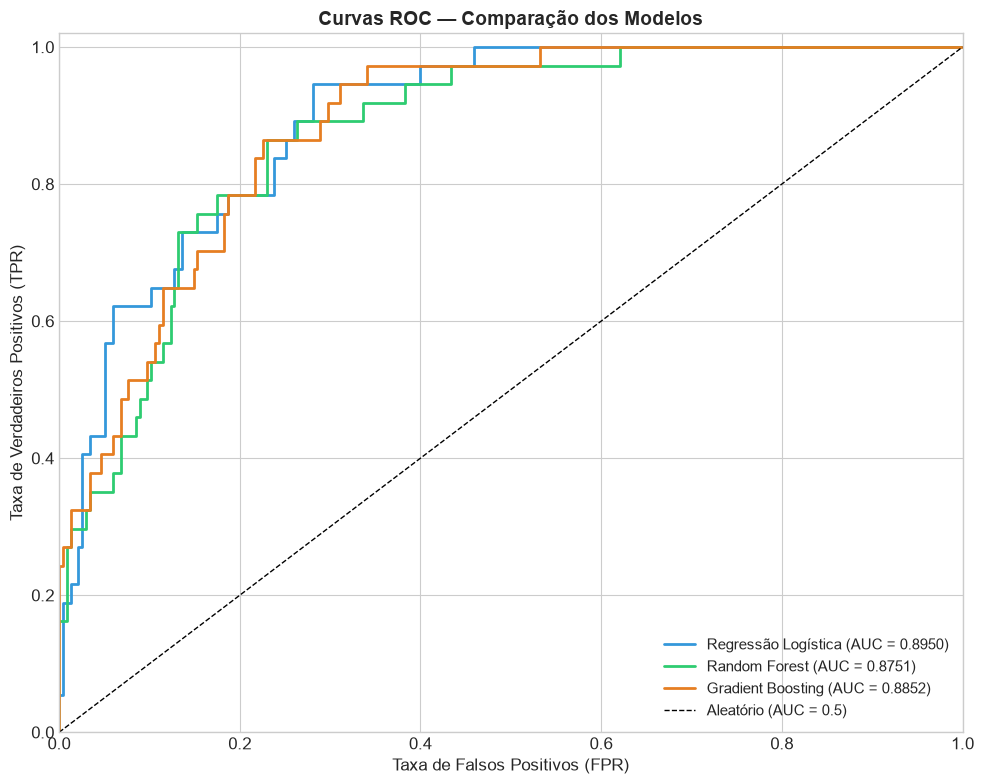

In [63]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#3498db', '#2ecc71', '#e67e22']

for i, (name, y_prob) in enumerate(probabilities.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.5)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'curvas_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Feature Importance Consolidada

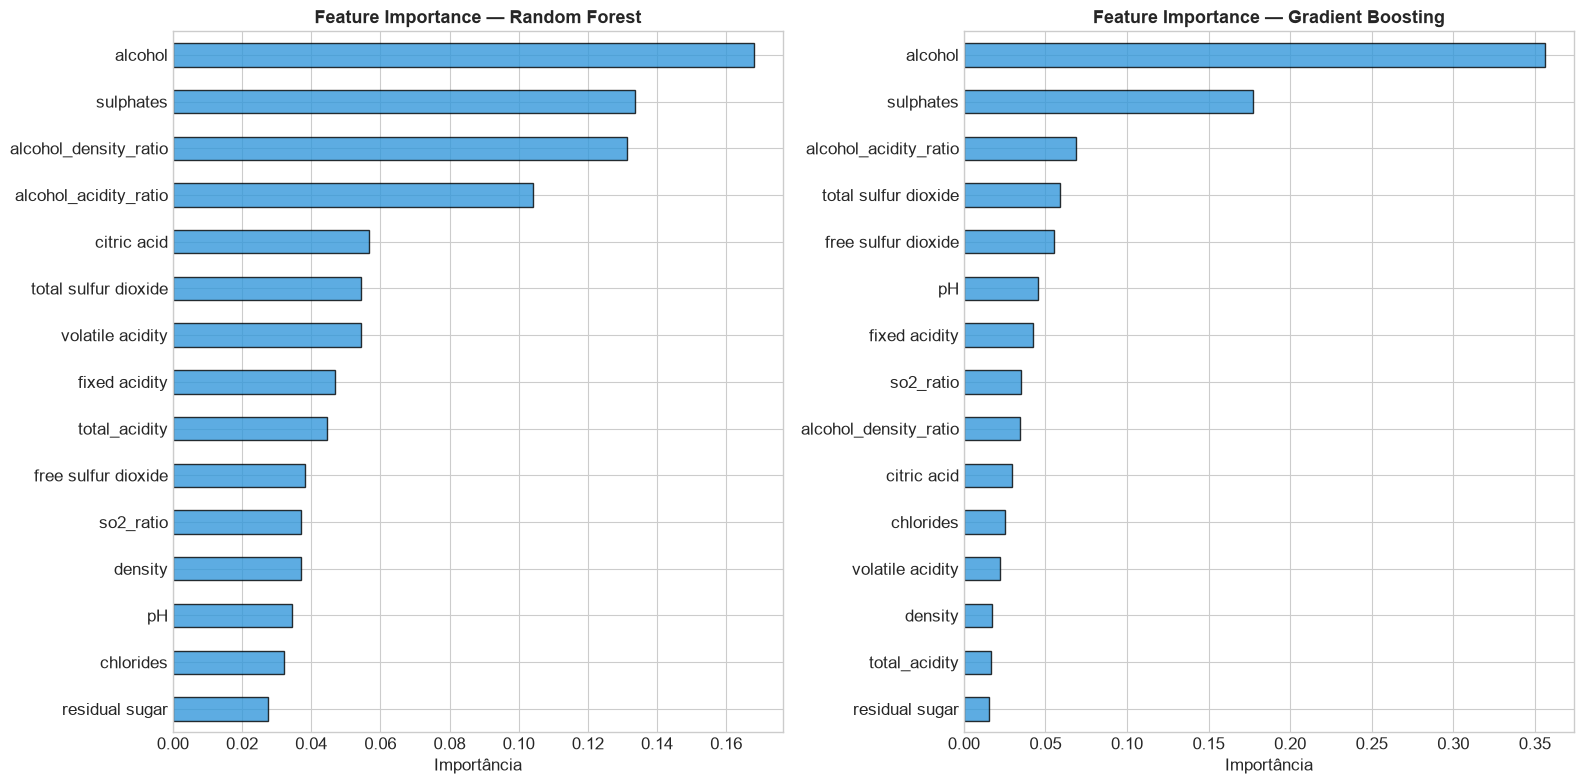

In [64]:
# Importância das features — Random Forest e Gradient Boosting
feature_names = X_train_eng.columns

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for idx, name in enumerate(['Random Forest', 'Gradient Boosting']):
    importances = models[name].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    
    feat_imp.plot(kind='barh', ax=axes[idx], color='#3498db', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Feature Importance — {name}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Importância')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'feature_importance_consolidada.png'), dpi=150, bbox_inches='tight')
plt.show()

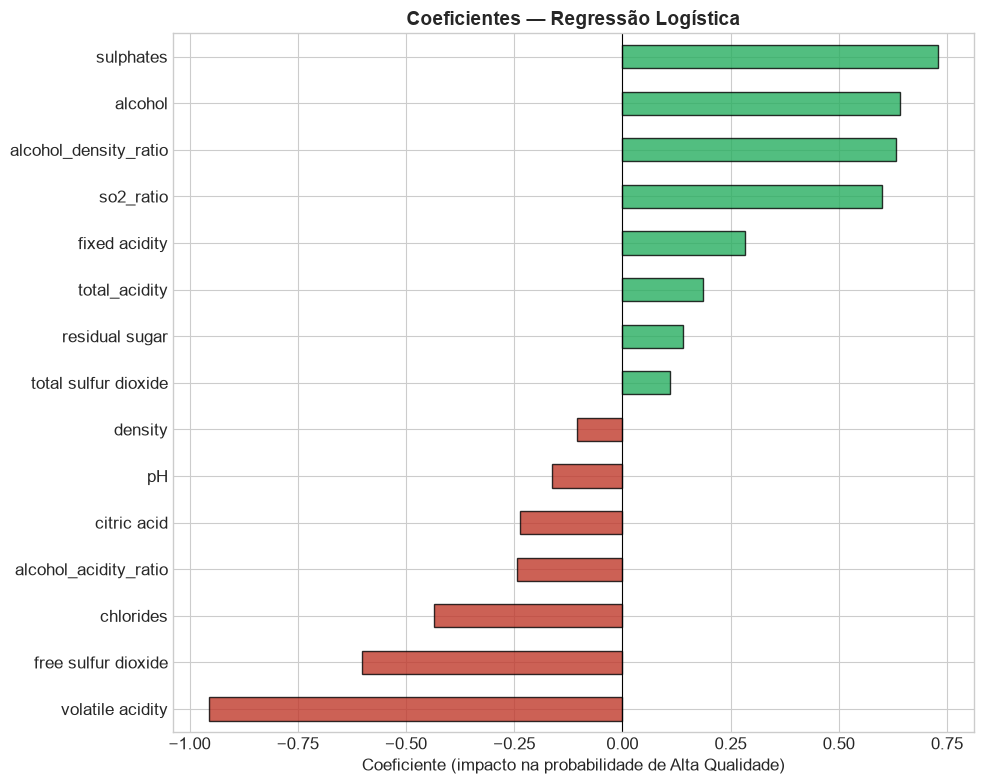

In [65]:
# Coeficientes da Regressão Logística
coefs = pd.Series(
    models['Regressão Logística'].coef_[0],
    index=feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if x < 0 else '#27ae60' for x in coefs.values]
coefs.plot(kind='barh', color=colors, edgecolor='black', alpha=0.8, ax=ax)
ax.set_title('Coeficientes — Regressão Logística', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente (impacto na probabilidade de Alta Qualidade)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'coeficientes_logistica.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Interpretação dos Resultados

### 7.1 Variáveis mais influentes na qualidade do vinho

Consolidando os resultados dos 3 modelos, as variáveis com maior influência na classificação de qualidade são:

1. 🍷 **Teor alcoólico (alcohol)** — Principal indicador de alta qualidade em todos os modelos. Vinhos com maior teor alcoólico tendem a ser produzidos a partir de uvas mais maduras, resultando em sabores mais complexos.

2. ⚗️ **Acidez volátil (volatile acidity)** — Forte impacto negativo. Níveis elevados indicam presença de ácido acético, associado a sabores de vinagre e degradação do vinho.

3. 🧪 **Sulfatos (sulphates)** — Impacto positivo. Atuam como conservantes e antioxidantes, preservando a qualidade organoléptica.

4. 🍋 **Ácido cítrico (citric acid)** — Contribui positivamente para o frescor e equilíbrio.

### 7.2 Implicações para o Processo de Produção

Com base nos insights do modelo, recomenda-se aos produtores:

- **Monitorar o teor alcoólico** durante a fermentação, otimizando o processo para atingir níveis ideais
- **Controlar rigorosamente a acidez volátil** para evitar degradação do sabor
- **Ajustar os níveis de sulfatos** para melhor preservação sem excesso
- **Manter o ácido cítrico** em níveis adequados para equilíbrio e frescor

### 7.3 Escolha do Melhor Modelo

A **Regressão Logística** apresentou o melhor desempenho geral (maior AUC-ROC), o que indica:
- O problema tem natureza **linearmente separável** em grande parte
- Modelos mais simples e interpretáveis podem ser preferíveis neste contexto
- A interpretação dos coeficientes facilita a comunicação com stakeholders

---
## 8. Conclusão

Neste projeto, desenvolvemos uma pipeline completa de Machine Learning para classificar a qualidade de vinhos tintos:

1. **Dados:** 1.599 amostras originais → 1.359 após remoção de 240 duplicatas (15,01%)
2. **EDA:** Identificamos padrões claros nas variáveis físico-químicas e desbalanceamento de classes (86% vs 14%)
3. **Pré-processamento:** Feature engineering (4 novas variáveis), padronização e SMOTE
4. **Modelagem:** 3 modelos treinados e comparados
5. **Melhor modelo:** Regressão Logística com AUC-ROC de ~0.90
6. **Insight principal:** Teor alcoólico e acidez volátil são os maiores determinantes da qualidade

O modelo demonstra que é possível prever a qualidade de vinhos com boa acurácia usando apenas dados físico-químicos, oferecendo uma ferramenta objetiva de apoio à decisão para produtores e enólogos.